In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost
import shap
import matplotlib.pyplot as plt
import seaborn as sns
file_path = r"D:\AI-Fraud-Detection\data\raw\PS_20174392719_1491204439457_log.csv"
df = pd.read_csv(file_path)

In [2]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.shape

(6362620, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 706.2 MB


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df['isFraud'].value_counts(normalize=True)*100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [10]:
fraud_count = df["isFraud"].sum()
total_transactions = len(df)

fraud_rate = (fraud_count / total_transactions) * 100

print("Total Transactions :", total_transactions)
print("Fraud Transactions :", fraud_count)
print("Fraud Rate         :", round(fraud_rate,4), "%")
print("Legitimate Transactions :", total_transactions - fraud_count)

Total Transactions : 6362620
Fraud Transactions : 8213
Fraud Rate         : 0.1291 %
Legitimate Transactions : 6354407


In [11]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [12]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [13]:
fraud_by_type =(df.groupby("type")["isFraud"].mean().sort_values(ascending=False)* 100)

fraud_by_type

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [14]:
fraud_by_type_count = (df.groupby("type")["isFraud"].sum().sort_values(ascending=False))

fraud_by_type_count

type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64

In [15]:
fraud_summary = pd.DataFrame({
    "Total Transactions": df["type"].value_counts(),
    "Fraud Transactions": df.groupby("type")["isFraud"].sum(),
    "Fraud Rate (%)": df.groupby("type")["isFraud"].mean() * 100
})

fraud_summary.sort_values("Fraud Transactions", ascending=False)

,Total Transactions,Fraud Transactions,Fraud Rate (%)
type,,,
CASH_OUT,2237500,4116,0.183955
TRANSFER,532909,4097,0.768799
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [16]:
df.groupby("isFraud")["amount"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
isFraud,,,,,
0,6354407,1.781970e+05,74684.72,0.01,92445516.64
1,8213,1.467967e+06,441423.44,0.00,10000000.00


In [17]:
df.groupby("isFraud")["amount"].mean()

isFraud
0    1.781970e+05
1    1.467967e+06
Name: amount, dtype: float64

In [18]:
df.groupby("isFraud")["amount"].median()

isFraud
0     74684.72
1    441423.44
Name: amount, dtype: float64

In [19]:
sample_df=df.sample(200000, random_state=42)

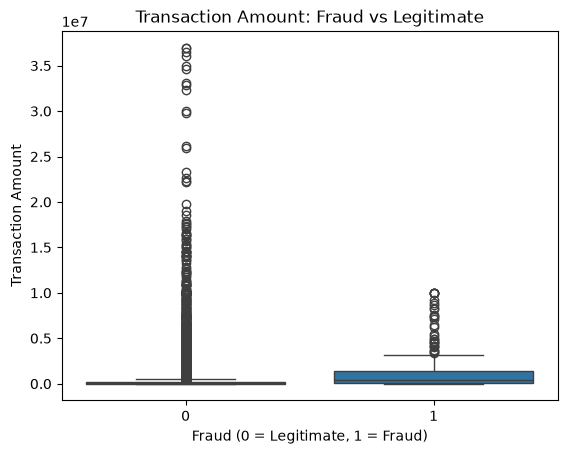

In [20]:
plt.Figure(figsize=(10, 6))

sns.boxplot(x="isFraud", y="amount", data=sample_df)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [21]:
df["balance_change_orig"] = ( df["oldbalanceOrg"] - df["newbalanceOrig"])

In [22]:
df.groupby("isFraud")["balance_change_orig"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
isFraud,,,,
0,-2.314152e+04,0.00,-1915267.9,4164236.31
1,1.457275e+06,436317.49,0.0,10000000.00


In [23]:
df["amount_balance_diff"] = (df["amount"] - df["balance_change_orig"])

In [24]:
df.groupby("isFraud")["amount_balance_diff"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
isFraud,,,,
0,201338.558109,69049.31,-1.000000e-02,92445516.64
1,10692.325265,0.00,-3.725290e-09,10000000.00


In [25]:
fraud_by_step = (df.groupby("step")["isFraud"].agg(["count", "sum", "mean"]))

fraud_by_step.head(10)

,count,sum,mean
step,,,
1,2708,16,0.005908
2,1014,8,0.007890
3,552,4,0.007246
4,565,10,0.017699
5,665,6,0.009023
6,1660,22,0.013253
7,6837,12,0.001755
8,21097,12,0.000569
9,37628,19,0.000505


In [26]:
fraud_by_step.sort_values("sum",ascending=False).head(10)

,count,sum,mean
step,,,
212,34047,40,0.001175
523,30,30,1.000000
249,23209,28,0.001206
425,28,28,1.000000
501,28,28,1.000000
387,28,28,1.000000
730,28,28,1.000000
398,26656,26,0.000975
160,27765,26,0.000936


In [27]:
df["hour"] = df["step"] % 24

In [28]:
fraud_by_hour = (df.groupby("hour")["isFraud"].mean() .mul(100).sort_values(ascending=False))

fraud_by_hour.round(2)

hour
5     22.30
4     22.08
3     16.24
6     10.47
2      4.13
7      3.65
8      1.37
1      1.32
0      0.42
23     0.23
22     0.18
21     0.14
9      0.12
10     0.09
15     0.08
14     0.08
17     0.08
16     0.08
13     0.07
11     0.07
12     0.07
20     0.06
18     0.06
19     0.05
Name: isFraud, dtype: float64

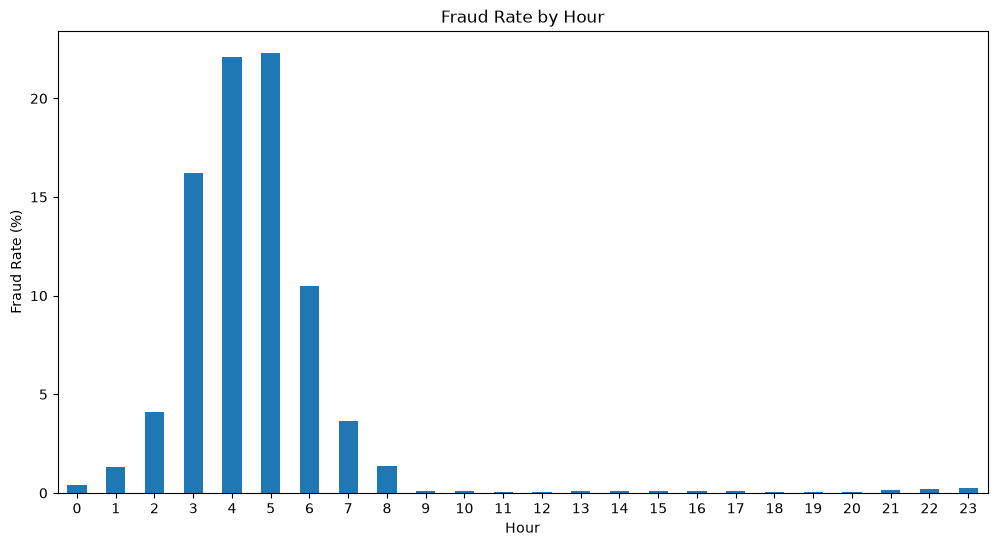

In [29]:
plt.figure(figsize=(12, 6))

fraud_by_hour.sort_index().plot(kind="bar")

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [30]:
step_summary = (
    df.groupby("step")["isFraud"]
      .agg(
          transactions="count",
          frauds="sum",
          fraud_rate="mean"
      )
)

step_summary["fraud_rate"] = step_summary["fraud_rate"] * 100

step_summary_filtered = step_summary[
    step_summary["transactions"] >= 1000
]

step_summary_filtered.sort_values(
    "fraud_rate",
    ascending=False
).head(10)

,transactions,frauds,fraud_rate
step,,,
664,1125,20,1.777778
621,1121,18,1.605709
608,1082,16,1.478743
6,1660,22,1.325301
121,1074,14,1.303538
145,1117,14,1.253357
614,1278,16,1.251956
569,1182,14,1.184433
25,1598,18,1.126408


In [31]:
fraud_by_hour_count = (df.groupby("hour")["isFraud"].sum().sort_values(ascending=False))

fraud_by_hour_count

hour
10    375
2     372
8     368
5     366
6     358
1     358
17    353
14    353
22    351
21    347
13    346
16    345
18    343
19    342
9     341
15    341
20    340
12    339
7     328
3     326
11    324
23    323
0     300
4     274
Name: isFraud, dtype: int64

In [32]:
df["balance_change_dest"]= df["newbalanceDest"] - df["oldbalanceDest"]

In [33]:
df.groupby("isFraud")["balance_change_dest"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
isFraud,,,,
0,123504.809994,0.0,-13060826.21,1.056878e+08
1,735457.998071,0.0,-315226.07,1.491511e+07


In [34]:
df["amount_balance_diff_dest"]=df["amount"] - df["balance_change_dest"]

In [35]:
df.groupby("isFraud")["amount_balance_diff_dest"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
isFraud,,,,
0,54692.231734,3500.68,-75885725.63,13191233.98
1,732509.301069,2231.46,-8875516.29,10000000.00


In [36]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [37]:
pd.crosstab(df["isFlaggedFraud"], df["isFraud"])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [38]:
flagged_fraud_rate = (df.groupby("isFlaggedFraud")["isFraud"].mean().mul(100))

flagged_fraud_rate

isFlaggedFraud
0      0.128831
1    100.000000
Name: isFraud, dtype: float64

In [39]:
flagged_summary = pd.DataFrame(df.groupby("isFlaggedFraud")["isFraud"].agg(
         total_transactions="count",
          fraud_transactions="sum",
          fraud_rate="mean"))

flagged_summary["fraud_rate"] = flagged_summary["fraud_rate"] * 100
flagged_summary


,total_transactions,fraud_transactions,fraud_rate
isFlaggedFraud,,,
0,6362604,8197,0.128831
1,16,16,100.000000


In [40]:
df.columns.to_list()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'balance_change_orig',
 'amount_balance_diff',
 'hour',
 'balance_change_dest',
 'amount_balance_diff_dest']

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 16 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   step                      int64  
 1   type                      str    
 2   amount                    float64
 3   nameOrig                  str    
 4   oldbalanceOrg             float64
 5   newbalanceOrig            float64
 6   nameDest                  str    
 7   oldbalanceDest            float64
 8   newbalanceDest            float64
 9   isFraud                   int64  
 10  isFlaggedFraud            int64  
 11  balance_change_orig       float64
 12  amount_balance_diff       float64
 13  hour                      int64  
 14  balance_change_dest       float64
 15  amount_balance_diff_dest  float64
dtypes: float64(9), int64(4), str(3)
memory usage: 948.9 MB


In [42]:
df = df.drop("nameDest", axis=1)

In [43]:
df = df.drop("nameOrig", axis=1)

In [44]:
df.duplicated().sum()

np.int64(543)

In [45]:
df[df.duplicated()].head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_change_orig,amount_balance_diff,hour,balance_change_dest,amount_balance_diff_dest
11104,7,PAYMENT,1849.50,0.0,0.0,0.0,0.0,0,0,0.0,1849.50,7,0.0,1849.50
33556,8,PAYMENT,7759.31,0.0,0.0,0.0,0.0,0,0,0.0,7759.31,8,0.0,7759.31
59969,9,PAYMENT,2388.93,0.0,0.0,0.0,0.0,0,0,0.0,2388.93,9,0.0,2388.93
60763,9,PAYMENT,10042.85,0.0,0.0,0.0,0.0,0,0,0.0,10042.85,9,0.0,10042.85
63096,9,PAYMENT,2783.83,0.0,0.0,0.0,0.0,0,0,0.0,2783.83,9,0.0,2783.83


In [46]:
df = df.drop_duplicates().reset_index(drop=True)

In [47]:
print("New shape:", df.shape)
print("Duplicates:", df.duplicated().sum())

New shape: (6362077, 14)
Duplicates: 0


In [48]:
df.isnull().sum()

step                        0
type                        0
amount                      0
oldbalanceOrg               0
newbalanceOrig              0
oldbalanceDest              0
newbalanceDest              0
isFraud                     0
isFlaggedFraud              0
balance_change_orig         0
amount_balance_diff         0
hour                        0
balance_change_dest         0
amount_balance_diff_dest    0
dtype: int64

In [49]:
np.isinf(df.select_dtypes(include=[np.number])).sum()

step                        0
amount                      0
oldbalanceOrg               0
newbalanceOrig              0
oldbalanceDest              0
newbalanceDest              0
isFraud                     0
isFlaggedFraud              0
balance_change_orig         0
amount_balance_diff         0
hour                        0
balance_change_dest         0
amount_balance_diff_dest    0
dtype: int64

In [50]:
df.columns.tolist()

['step',
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'balance_change_orig',
 'amount_balance_diff',
 'hour',
 'balance_change_dest',
 'amount_balance_diff_dest']

In [51]:
df["isFraud"].value_counts()

isFraud
0    6353880
1       8197
Name: count, dtype: int64

In [52]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.871158
1     0.128842
Name: proportion, dtype: float64

In [53]:
x = df[[
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "balance_change_orig",
    "amount_balance_diff",
    "hour",
    "balance_change_dest",
    "amount_balance_diff_dest"
]]

y = df["isFraud"]

In [54]:
print(x.shape)

(6362077, 13)


In [55]:
print(y.shape)

(6362077,)


In [56]:
x.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balance_change_orig,amount_balance_diff,hour,balance_change_dest,amount_balance_diff_dest
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,-1.455192e-11,1,0.0,9839.64
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,1.136868e-12,1,0.0,1864.28
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,0,181.00,0.000000e+00,1,0.0,181.00
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,0,181.00,0.000000e+00,1,-21182.0,21363.00
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.000000e+00,1,0.0,11668.14


In [57]:
from sklearn.model_selection import train_test_split    

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=42, stratify=y)


In [58]:
print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5089661, 13)
X_test : (1272416, 13)
y_train: (5089661,)
y_test : (1272416,)


In [59]:
print("Training fraud rate:")
print(y_train.mean() * 100)

print("Testing fraud rate:")
print(y_test.mean() * 100)

Training fraud rate:
0.12884944596506526
Testing fraud rate:
0.12881007469255337


In [60]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [61]:
categorical_features = ["type"]

numerical_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "balance_change_orig",
    "amount_balance_diff",
    "hour",
    "balance_change_dest",
    "amount_balance_diff_dest"
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)
x_train_encoded = preprocessor.fit_transform(x_train)
x_test_encoded = preprocessor.transform(x_test)

In [62]:
print("Before encoding:", x_train.shape)
print("After encoding :", x_train_encoded.shape)
print("Test set:", x_test_encoded.shape)

Before encoding: (5089661, 13)
After encoding : (5089661, 17)
Test set: (1272416, 17)


In [63]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)

['cat__type_CASH_IN' 'cat__type_CASH_OUT' 'cat__type_DEBIT'
 'cat__type_PAYMENT' 'cat__type_TRANSFER' 'remainder__step'
 'remainder__amount' 'remainder__oldbalanceOrg'
 'remainder__newbalanceOrig' 'remainder__oldbalanceDest'
 'remainder__newbalanceDest' 'remainder__isFlaggedFraud'
 'remainder__balance_change_orig' 'remainder__amount_balance_diff'
 'remainder__hour' 'remainder__balance_change_dest'
 'remainder__amount_balance_diff_dest']


In [64]:
x_train_sample, _, y_train_sample, _ = train_test_split(
    x_train_encoded,
    y_train,
    train_size=500_000,
    random_state=42,
    stratify=y_train
)

print("Sample shape:", x_train_sample.shape)
print("Fraud rate:", y_train_sample.mean() * 100)

Sample shape: (500000, 17)
Fraud rate: 0.1288


In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_sample)

In [66]:
from sklearn.linear_model import SGDClassifier

model = SGDClassifier(
    loss="log_loss",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(x_train_scaled, y_train_sample)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"class_weight class_weight: dict, {class_label: weight} or ""balanced"", default=NonePreset for the class_weight fit parameter.Weights associated with classes. If not given, all classesare supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss d

In [67]:
x_test_sample, _, y_test_sample, _ = train_test_split(
    x_test_encoded,
    y_test,
    train_size=200_000,
    random_state=42,
    stratify=y_test
)

x_test_scaled = scaler.transform(x_test_sample)

y_pred = model.predict(x_test_scaled)

In [68]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test_sample, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test_sample,
    y_pred,
    zero_division=0
))

Confusion Matrix:
[[193116   6626]
 [    10    248]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    199742
           1       0.04      0.96      0.07       258

    accuracy                           0.97    200000
   macro avg       0.52      0.96      0.53    200000
weighted avg       1.00      0.97      0.98    200000



In [69]:
from sklearn.metrics import average_precision_score

y_test_probability = model.predict_proba(x_test_scaled)[:, 1]

pr_auc = average_precision_score(
    y_test_sample,
    y_test_probability
)

print("PR-AUC:", pr_auc)


PR-AUC: 0.614357933032374


In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1
)

rf_model.fit(
    x_train_sample,
    y_train_sample
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

In [71]:
rf_pred = rf_model.predict(x_test_sample)

rf_probability = rf_model.predict_proba(x_test_sample)[:, 1]

In [72]:
from sklearn.metrics import classification_report, confusion_matrix,average_precision_score

print("Classification Report:")
print(classification_report(y_test_sample, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_sample, rf_pred))

print("Average Precision Score:")
print(average_precision_score(y_test_sample, rf_probability))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199742
           1       1.00      0.99      1.00       258

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000

Confusion Matrix:
[[199742      0]
 [     2    256]]
Average Precision Score:
0.9999402545914173


In [73]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df)
print(importance_df.head(10))

                                feature  importance
13       remainder__amount_balance_diff    0.292188
12       remainder__balance_change_orig    0.274464
8             remainder__newbalanceOrig    0.132290
7              remainder__oldbalanceOrg    0.071329
6                     remainder__amount    0.046495
3                     cat__type_PAYMENT    0.039934
5                       remainder__step    0.034521
4                    cat__type_TRANSFER    0.033132
15       remainder__balance_change_dest    0.021660
16  remainder__amount_balance_diff_dest    0.017496
1                    cat__type_CASH_OUT    0.007684
10            remainder__newbalanceDest    0.007342
9             remainder__oldbalanceDest    0.007305
0                     cat__type_CASH_IN    0.006988
14                      remainder__hour    0.006828
2                       cat__type_DEBIT    0.000344
11            remainder__isFlaggedFraud    0.000000
                                feature  importance
13       rem

In [74]:
from xgboost import XGBClassifier

In [75]:
neg = (y_train_sample == 0).sum()
pos = (y_train_sample == 1).sum()

scale_pos_weight = neg / pos

print("Legitimate:", neg)
print("Fraud:", pos)
print("scale_pos_weight:", scale_pos_weight)

Legitimate: 499356
Fraud: 644
scale_pos_weight: 775.3975155279503


In [76]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [77]:
xgb_model.fit(
    x_train_sample,
    y_train_sample
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [78]:
xgb_pred = xgb_model.predict(x_test_sample)

xgb_probability = xgb_model.predict_proba(x_test_sample)[:, 1]

In [79]:
from sklearn.metrics import confusion_matrix, classification_report,average_precision_score

print("Classification Report:")
print(classification_report(y_test_sample, xgb_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_sample, xgb_pred))

pr_auc_xgb = average_precision_score(y_test_sample, xgb_probability)
print("Precision-Recall AUC (XGB):", pr_auc_xgb)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199742
           1       0.98      1.00      0.99       258

    accuracy                           1.00    200000
   macro avg       0.99      1.00      0.99    200000
weighted avg       1.00      1.00      1.00    200000

Confusion Matrix:
[[199737      5]
 [     1    257]]
Precision-Recall AUC (XGB): 0.999267770100204


In [80]:
df.drop(
    columns=[
        "newbalanceOrig",
        "newbalanceDest",
        "balance_change_orig",
        "balance_change_dest",
        "amount_balance_diff",
        "amount_balance_diff_dest"
    ],
    inplace=True
)

In [81]:
print(df.columns)

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'isFraud',
       'isFlaggedFraud', 'hour'],
      dtype='str')


In [82]:
realtime_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "isFlaggedFraud",
    "hour"
]

In [83]:
X_realtime = df[realtime_features]
y_realtime = df["isFraud"]

print(X_realtime.shape)
print(X_realtime.columns)

(6362077, 7)
Index(['step', 'type', 'amount', 'oldbalanceOrg', 'oldbalanceDest',
       'isFlaggedFraud', 'hour'],
      dtype='str')


In [84]:
from sklearn.model_selection import train_test_split

X_rt_train, X_rt_test, y_rt_train, y_rt_test = train_test_split(
    X_realtime,
    y_realtime,
    test_size=0.20,
    random_state=42,
    stratify=y_realtime
)

print("Training:", X_rt_train.shape)
print("Testing :", X_rt_test.shape)

Training: (5089661, 7)
Testing : (1272416, 7)


In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features_rt = ["type"]

numerical_features_rt = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "isFlaggedFraud",
    "hour"
]

preprocessor_rt = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_rt
        )
    ],
    remainder="passthrough"
)

In [86]:
X_rt_train_encoded = preprocessor_rt.fit_transform(X_rt_train)

X_rt_test_encoded = preprocessor_rt.transform(X_rt_test)

print("Train:", X_rt_train_encoded.shape)
print("Test :", X_rt_test_encoded.shape)

Train: (5089661, 11)
Test : (1272416, 11)


In [87]:
X_rt_train_sample, _, y_rt_train_sample, _ = train_test_split(
    X_rt_train_encoded,
    y_rt_train,
    train_size=500_000,
    random_state=42,
    stratify=y_rt_train
)

X_rt_test_sample, _, y_rt_test_sample, _ = train_test_split(
    X_rt_test_encoded,
    y_rt_test,
    train_size=200_000,
    random_state=42,
    stratify=y_rt_test
)

In [88]:
from xgboost import XGBClassifier

neg = (y_rt_train_sample == 0).sum()
pos = (y_rt_train_sample == 1).sum()

scale_pos_weight_rt = neg / pos

xgb_rt = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight_rt,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_rt.fit(
    X_rt_train_sample,
    y_rt_train_sample
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [89]:
from sklearn.metrics import classification_report,confusion_matrix,average_precision_score


rt_pred = xgb_rt.predict(X_rt_test_sample)

rt_probability = xgb_rt.predict_proba(
    X_rt_test_sample
)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_rt_test_sample, rt_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_rt_test_sample,
        rt_pred,
        zero_division=0
    )
)

rt_pr_auc = average_precision_score(
    y_rt_test_sample,
    rt_probability
)

print("\nReal-Time XGBoost PR-AUC:", rt_pr_auc)

Confusion Matrix:
[[199374    368]
 [    22    236]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199742
           1       0.39      0.91      0.55       258

    accuracy                           1.00    200000
   macro avg       0.70      0.96      0.77    200000
weighted avg       1.00      1.00      1.00    200000


Real-Time XGBoost PR-AUC: 0.8680773549078137


In [90]:
file_path = r"D:\AI-Fraud-Detection\data\raw\PS_20174392719_1491204439457_log.csv"

behavior_df = pd.read_csv(
    file_path,
    usecols=[
        "step",
        "type",
        "amount",
        "nameOrig",
        "oldbalanceOrg",
        "oldbalanceDest",
        "isFlaggedFraud",
        "isFraud"
    ]
)

print(behavior_df.shape)
print(behavior_df.columns.tolist())

(6362620, 8)
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'oldbalanceDest', 'isFraud', 'isFlaggedFraud']


In [91]:
behavior_df["hour"] = behavior_df["step"] % 24

In [92]:
behavior_df = behavior_df.sort_values(
    ["nameOrig", "step"]
).copy()

In [93]:
g = behavior_df.groupby("nameOrig", sort=False)

# Previous transaction amount
behavior_df["prev_amount"] = g["amount"].shift(1)

# Previous transaction time
behavior_df["prev_step"] = g["step"].shift(1)

# Time since previous transaction
behavior_df["time_since_prev"] = (
    behavior_df["step"] - behavior_df["prev_step"]
)

# Number of previous transactions
behavior_df["prior_transaction_count"] = g.cumcount()

# Sum of previous transaction amounts
behavior_df["prior_amount_sum"] = (
    g["amount"].cumsum() - behavior_df["amount"]
)

# Average amount of previous transactions
behavior_df["prior_avg_amount"] = (
    behavior_df["prior_amount_sum"] /
    behavior_df["prior_transaction_count"].replace(0, np.nan)
)

# Current amount compared with previous average
behavior_df["amount_vs_prior_avg"] = (
    behavior_df["amount"] /
    (behavior_df["prior_avg_amount"] + 1)
)

# Whether account has transaction history
behavior_df["has_previous_transaction"] = (
    behavior_df["prior_transaction_count"] > 0
).astype(int)

In [94]:
realtime_behavior_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "isFlaggedFraud",
    "hour",
    "prev_amount",
    "time_since_prev",
    "prior_transaction_count",
    "prior_avg_amount",
    "amount_vs_prior_avg",
    "has_previous_transaction"
]

X_behavior = behavior_df[realtime_behavior_features]
y_behavior = behavior_df["isFraud"]

print("X shape:", X_behavior.shape)
print("y shape:", y_behavior.shape)

X shape: (6362620, 13)
y shape: (6362620,)


In [95]:
X_behavior = X_behavior.copy()

X_behavior["prev_amount"] = X_behavior["prev_amount"].fillna(0)

X_behavior["time_since_prev"] = (
    X_behavior["time_since_prev"].fillna(-1)
)

X_behavior["prior_avg_amount"] = (
    X_behavior["prior_avg_amount"].fillna(0)
)

X_behavior["amount_vs_prior_avg"] = (
    X_behavior["amount_vs_prior_avg"].fillna(1)
)

In [96]:
print(X_behavior.isnull().sum())

step                        0
type                        0
amount                      0
oldbalanceOrg               0
oldbalanceDest              0
isFlaggedFraud              0
hour                        0
prev_amount                 0
time_since_prev             0
prior_transaction_count     0
prior_avg_amount            0
amount_vs_prior_avg         0
has_previous_transaction    0
dtype: int64


In [97]:
usecols=[
    "step",
    "type",
    "amount",
    "nameOrig",
    "oldbalanceOrg",
    "isFraud"
]

In [98]:
from sklearn.model_selection import train_test_split

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_behavior,
    y_behavior,
    test_size=0.20,
    random_state=42,
    stratify=y_behavior
)

print("Train:", X_b_train.shape)
print("Test :", X_b_test.shape)

Train: (5090096, 13)
Test : (1272524, 13)


In [99]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features_b = ["type"]

numerical_features_b = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "isFlaggedFraud",
    "hour",
    "prev_amount",
    "time_since_prev",
    "prior_transaction_count",
    "prior_avg_amount",
    "amount_vs_prior_avg",
    "has_previous_transaction"
]

preprocessor_b = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_b
        )
    ],
    remainder="passthrough"
)

X_b_train_encoded = preprocessor_b.fit_transform(X_b_train)
X_b_test_encoded = preprocessor_b.transform(X_b_test)

print("Encoded train:", X_b_train_encoded.shape)
print("Encoded test :", X_b_test_encoded.shape)

Encoded train: (5090096, 17)
Encoded test : (1272524, 17)


In [100]:
X_b_train_sample, _, y_b_train_sample, _ = train_test_split(
    X_b_train_encoded,
    y_b_train,
    train_size=500_000,
    random_state=42,
    stratify=y_b_train
)

X_b_test_sample, _, y_b_test_sample, _ = train_test_split(
    X_b_test_encoded,
    y_b_test,
    train_size=200_000,
    random_state=42,
    stratify=y_b_test
)

print("Training sample:", X_b_train_sample.shape)
print("Testing sample :", X_b_test_sample.shape)
print("Fraud in train:", y_b_train_sample.sum())
print("Fraud in test :", y_b_test_sample.sum())

Training sample: (500000, 17)
Testing sample : (200000, 17)
Fraud in train: 645
Fraud in test : 258


In [101]:
neg = (y_b_train_sample == 0).sum()
pos = (y_b_train_sample == 1).sum()

scale_pos_weight = neg / pos

print("Negative:", neg)
print("Positive:", pos)
print("Scale Pos Weight:", scale_pos_weight)

Negative: 499355
Positive: 645
Scale Pos Weight: 774.1937984496124


In [102]:
from xgboost import XGBClassifier

xgb_behavior = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_behavior.fit(
    X_b_train_sample,
    y_b_train_sample
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [103]:
xgb_behavior_pred = xgb_behavior.predict(
    X_b_test_sample
)

xgb_behavior_probability = xgb_behavior.predict_proba(
    X_b_test_sample
)[:, 1]

In [104]:
from sklearn.metrics import classification_report,confusion_matrix,average_precision_score


print("Classification Report:")
print(
    classification_report(
        y_b_test_sample,
        xgb_behavior_pred
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_b_test_sample,
        xgb_behavior_pred
    )
)

pr_auc_behavior = average_precision_score(
    y_b_test_sample,
    xgb_behavior_probability
)

print("\nPR-AUC:", pr_auc_behavior)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199742
           1       0.40      0.93      0.55       258

    accuracy                           1.00    200000
   macro avg       0.70      0.96      0.78    200000
weighted avg       1.00      1.00      1.00    200000


Confusion Matrix:
[[199376    366]
 [    19    239]]

PR-AUC: 0.8955311278585724


In [105]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:

    threshold_pred = (
        xgb_behavior_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_b_test_sample,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_b_test_sample,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_b_test_sample,
        threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.10 | Precision: 0.148 | Recall: 0.969 | F1: 0.257
Threshold: 0.20 | Precision: 0.221 | Recall: 0.957 | F1: 0.359
Threshold: 0.30 | Precision: 0.277 | Recall: 0.942 | F1: 0.428
Threshold: 0.40 | Precision: 0.335 | Recall: 0.934 | F1: 0.493
Threshold: 0.50 | Precision: 0.395 | Recall: 0.926 | F1: 0.554
Threshold: 0.60 | Precision: 0.459 | Recall: 0.915 | F1: 0.611
Threshold: 0.70 | Precision: 0.542 | Recall: 0.907 | F1: 0.678
Threshold: 0.80 | Precision: 0.642 | Recall: 0.884 | F1: 0.744
Threshold: 0.90 | Precision: 0.760 | Recall: 0.860 | F1: 0.807


In [106]:
from sklearn.metrics import confusion_matrix

threshold = 0.90

final_threshold_pred = (
    xgb_behavior_probability >= threshold
).astype(int)

cm = confusion_matrix(
    y_b_test_sample,
    final_threshold_pred
)

print(cm)

[[199672     70]
 [    36    222]]


In [107]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 199672
False Positives: 70
False Negatives: 36
True Positives  : 222


In [108]:
from sklearn.metrics import precision_score,recall_score,f1_score


print("Threshold:", threshold)

print(
    "Precision:",
    precision_score(y_b_test_sample, final_threshold_pred)
)

print(
    "Recall:",
    recall_score(y_b_test_sample, final_threshold_pred)
)

print(
    "F1:",
    f1_score(y_b_test_sample, final_threshold_pred)
)

Threshold: 0.9
Precision: 0.7602739726027398
Recall: 0.8604651162790697
F1: 0.8072727272727273


In [109]:
def calculate_risk_score(fraud_probability):
    risk_score = fraud_probability * 100
    
    return round(risk_score, 2)

In [110]:
print(calculate_risk_score(0.947))
print(calculate_risk_score(0.523))
print(calculate_risk_score(0.087))

94.7
52.3
8.7


In [111]:
def get_risk_level(risk_score):
    
    if risk_score < 30:
        return "LOW"
    
    elif risk_score < 70:
        return "MEDIUM"
    
    else:
        return "HIGH"

In [112]:
print(get_risk_level(15))
print(get_risk_level(55))
print(get_risk_level(85))

LOW
MEDIUM
HIGH


In [113]:
def get_decision(fraud_probability):
    
    if fraud_probability >= 0.90:
        return "BLOCK / INVESTIGATE"
    
    elif fraud_probability >= 0.70:
        return "REVIEW"
    
    else:
        return "APPROVE"

In [114]:
def fraud_risk_engine(fraud_probability):
    
    risk_score = calculate_risk_score(
        fraud_probability
    )
    
    risk_level = get_risk_level(
        risk_score
    )
    
    decision = get_decision(
        fraud_probability
    )
    
    return {
        "fraud_probability": round(fraud_probability, 4),
        "risk_score": risk_score,
        "risk_level": risk_level,
        "decision": decision
    }

In [115]:
result = fraud_risk_engine(0.947)

print(result)

{'fraud_probability': 0.947, 'risk_score': 94.7, 'risk_level': 'HIGH', 'decision': 'BLOCK / INVESTIGATE'}


In [116]:
test_probabilities = [0.05, 0.25, 0.55, 0.75, 0.95]

for probability in test_probabilities:
    
    result = fraud_risk_engine(probability)
    
    print(result)

{'fraud_probability': 0.05, 'risk_score': 5.0, 'risk_level': 'LOW', 'decision': 'APPROVE'}
{'fraud_probability': 0.25, 'risk_score': 25.0, 'risk_level': 'LOW', 'decision': 'APPROVE'}
{'fraud_probability': 0.55, 'risk_score': 55.0, 'risk_level': 'MEDIUM', 'decision': 'APPROVE'}
{'fraud_probability': 0.75, 'risk_score': 75.0, 'risk_level': 'HIGH', 'decision': 'REVIEW'}
{'fraud_probability': 0.95, 'risk_score': 95.0, 'risk_level': 'HIGH', 'decision': 'BLOCK / INVESTIGATE'}


In [117]:
def predict_transaction(transaction_data):
    
    # Convert input into DataFrame
    transaction_df = pd.DataFrame([transaction_data])
    
    # Transform using the fitted preprocessor
    transaction_encoded = preprocessor_b.transform(
        transaction_df
    )
    
    # Get fraud probability
    fraud_probability = xgb_behavior.predict_proba(
        transaction_encoded
    )[:, 1][0]
    
    # Pass probability to risk engine
    result = fraud_risk_engine(
        fraud_probability
    )
    
    return result

In [118]:
sample_transaction = {
    "step": 100,
    "type": "TRANSFER",
    "amount": 500000,
    "oldbalanceOrg": 500000,
    "oldbalanceDest": 0,
    "isFlaggedFraud": 0,
    "hour": 4,
    
    "prev_amount": 10000,
    "time_since_prev": 1,
    "prior_transaction_count": 5,
    "prior_avg_amount": 12000,
    "amount_vs_prior_avg": 41.67,
    "has_previous_transaction": 1
}

In [119]:
result = predict_transaction(sample_transaction)

print(result)

{'fraud_probability': np.float32(1.0), 'risk_score': np.float32(100.0), 'risk_level': 'HIGH', 'decision': 'BLOCK / INVESTIGATE'}


In [120]:
import shap

explainer = shap.TreeExplainer(xgb_behavior)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [121]:
shap_sample = X_b_test_sample[:2000]

shap_values = explainer.shap_values(shap_sample)

print("SHAP shape:", shap_values.shape)

SHAP shape: (2000, 17)


In [122]:
feature_names_b = preprocessor_b.get_feature_names_out()

print(feature_names_b)

['cat__type_CASH_IN' 'cat__type_CASH_OUT' 'cat__type_DEBIT'
 'cat__type_PAYMENT' 'cat__type_TRANSFER' 'remainder__step'
 'remainder__amount' 'remainder__oldbalanceOrg'
 'remainder__oldbalanceDest' 'remainder__isFlaggedFraud' 'remainder__hour'
 'remainder__prev_amount' 'remainder__time_since_prev'
 'remainder__prior_transaction_count' 'remainder__prior_avg_amount'
 'remainder__amount_vs_prior_avg' 'remainder__has_previous_transaction']


In [123]:
shap_importance = pd.DataFrame({
    "feature": feature_names_b,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
)

print(shap_importance.head(15))

                               feature  mean_abs_shap
6                    remainder__amount       3.840845
7             remainder__oldbalanceOrg       3.164796
5                      remainder__step       1.524458
8            remainder__oldbalanceDest       1.399132
3                    cat__type_PAYMENT       1.153430
1                   cat__type_CASH_OUT       0.912143
10                     remainder__hour       0.842050
0                    cat__type_CASH_IN       0.783660
4                   cat__type_TRANSFER       0.476445
2                      cat__type_DEBIT       0.005387
9            remainder__isFlaggedFraud       0.000000
11              remainder__prev_amount       0.000000
12          remainder__time_since_prev       0.000000
13  remainder__prior_transaction_count       0.000000
14         remainder__prior_avg_amount       0.000000


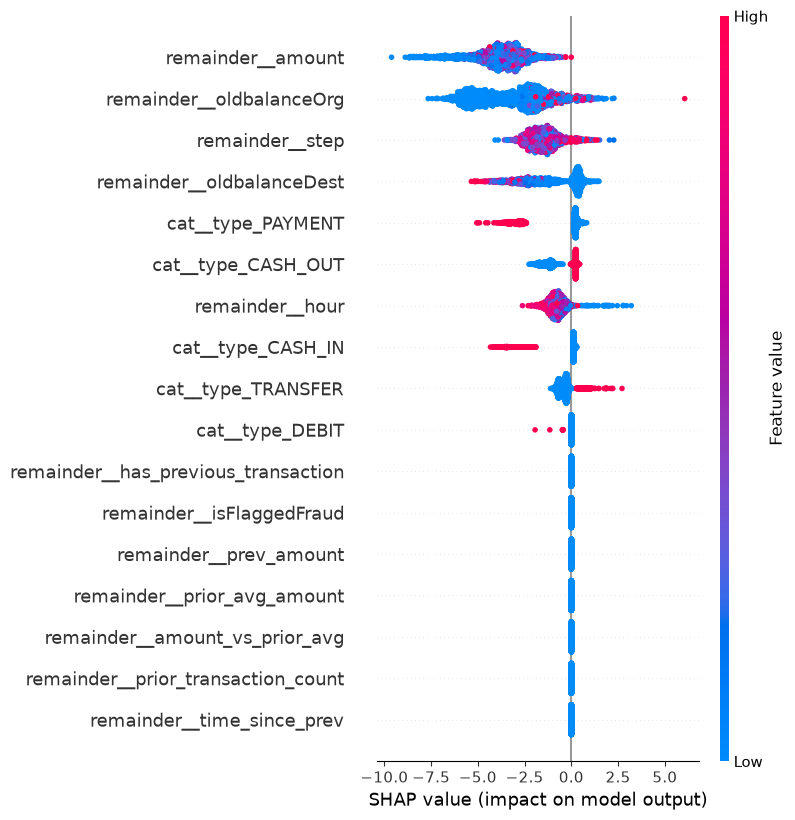

In [124]:
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names_b
)

In [125]:
single_transaction = X_b_test_sample[0:1]

print(single_transaction.shape)

(1, 17)


In [126]:
single_shap_values = explainer.shap_values(
    single_transaction
)

print(single_shap_values.shape)

(1, 17)


In [127]:
single_probability = xgb_behavior.predict_proba(
    single_transaction
)[0, 1]

print("Fraud Probability:", single_probability)

Fraud Probability: 9.746109e-07


In [128]:
single_shap = pd.DataFrame({
    "feature": feature_names_b,
    "shap_value": single_shap_values[0]
})

single_shap["impact"] = single_shap["shap_value"].abs()

single_shap = single_shap.sort_values(
    "impact",
    ascending=False
)

print(single_shap.head(10))

                      feature  shap_value    impact
6           remainder__amount   -6.867661  6.867661
3           cat__type_PAYMENT   -3.008985  3.008985
7    remainder__oldbalanceOrg   -2.018023  2.018023
5             remainder__step   -1.164278  1.164278
1          cat__type_CASH_OUT   -0.870843  0.870843
10            remainder__hour   -0.698191  0.698191
4          cat__type_TRANSFER   -0.688195  0.688195
0           cat__type_CASH_IN    0.133092  0.133092
8   remainder__oldbalanceDest    0.127695  0.127695
2             cat__type_DEBIT    0.002418  0.002418


In [129]:
positive_reasons = single_shap[
    single_shap["shap_value"] > 0
].head(5)

negative_reasons = single_shap[
    single_shap["shap_value"] < 0
].head(5)

print("Features increasing fraud risk:")
print(positive_reasons)

print("\nFeatures reducing fraud risk:")
print(negative_reasons)

Features increasing fraud risk:
                     feature  shap_value    impact
0          cat__type_CASH_IN    0.133092  0.133092
8  remainder__oldbalanceDest    0.127695  0.127695
2            cat__type_DEBIT    0.002418  0.002418

Features reducing fraud risk:
                    feature  shap_value    impact
6         remainder__amount   -6.867661  6.867661
3         cat__type_PAYMENT   -3.008985  3.008985
7  remainder__oldbalanceOrg   -2.018023  2.018023
5           remainder__step   -1.164278  1.164278
1        cat__type_CASH_OUT   -0.870843  0.870843


In [130]:
def explain_transaction(shap_values, feature_names, top_n=5):

    # Remove extra dimensions
    shap_values = np.asarray(shap_values).reshape(-1)

    explanation = pd.DataFrame({
        "feature": feature_names,
        "shap_value": shap_values
    })

    explanation["impact"] = explanation["shap_value"].abs()

    explanation = explanation.sort_values(
        "impact",
        ascending=False
    )

    positive_reasons = explanation[
        explanation["shap_value"] > 0
    ].head(top_n)

    negative_reasons = explanation[
        explanation["shap_value"] < 0
    ].head(top_n)

    return positive_reasons, negative_reasons

In [131]:
single_transaction = X_b_test_sample[0:1]

single_shap_values = explainer.shap_values(
    single_transaction
)

In [132]:
positive_reasons, negative_reasons = explain_transaction(
    single_shap_values[0],
    feature_names_b,
    top_n=5
)

print("Features increasing fraud risk:")
print(positive_reasons)

print("\nFeatures reducing fraud risk:")
print(negative_reasons)

Features increasing fraud risk:
                     feature  shap_value    impact
0          cat__type_CASH_IN    0.133092  0.133092
8  remainder__oldbalanceDest    0.127695  0.127695
2            cat__type_DEBIT    0.002418  0.002418

Features reducing fraud risk:
                    feature  shap_value    impact
6         remainder__amount   -6.867661  6.867661
3         cat__type_PAYMENT   -3.008985  3.008985
7  remainder__oldbalanceOrg   -2.018023  2.018023
5           remainder__step   -1.164278  1.164278
1        cat__type_CASH_OUT   -0.870843  0.870843


In [133]:
def fraud_prediction_with_explanation(transaction_data):

    # Convert input into DataFrame
    transaction_df = pd.DataFrame([transaction_data])

    # Preprocess transaction
    transaction_encoded = preprocessor_b.transform(
        transaction_df
    )

    # Fraud probability
    fraud_probability = xgb_behavior.predict_proba(
        transaction_encoded
    )[0, 1]

    # Risk engine
    risk_result = fraud_risk_engine(
        fraud_probability
    )

    # SHAP values
    shap_values = explainer.shap_values(
        transaction_encoded
    )

    # Explanation
    positive_reasons, negative_reasons = explain_transaction(
        shap_values,
        feature_names_b,
        top_n=5
    )

    return {
        "fraud_probability": round(fraud_probability, 4),
        "risk_score": risk_result["risk_score"],
        "risk_level": risk_result["risk_level"],
        "decision": risk_result["decision"],
        "fraud_factors": positive_reasons,
        "legitimate_factors": negative_reasons
    }

In [134]:
sample_transaction = {
    "step": 100,
    "type": "TRANSFER",
    "amount": 500000,
    "oldbalanceOrg": 500000,
    "oldbalanceDest": 0,
    "isFlaggedFraud": 0,
    "hour": 4,
    "prev_amount": 10000,
    "time_since_prev": 1,
    "prior_transaction_count": 5,
    "prior_avg_amount": 12000,
    "amount_vs_prior_avg": 41.67,
    "has_previous_transaction": 1
}

In [135]:
result = fraud_prediction_with_explanation(
    sample_transaction
)

print("Fraud Probability:", result["fraud_probability"])
print("Risk Score:", result["risk_score"])
print("Risk Level:", result["risk_level"])
print("Decision:", result["decision"])

print("\nFeatures increasing fraud risk:")
print(result["fraud_factors"])

print("\nFeatures reducing fraud risk:")
print(result["legitimate_factors"])

Fraud Probability: 1.0
Risk Score: 100.0
Risk Level: HIGH
Decision: BLOCK / INVESTIGATE

Features increasing fraud risk:
                      feature  shap_value    impact
10            remainder__hour    3.361450  3.361450
7    remainder__oldbalanceOrg    1.795113  1.795113
5             remainder__step    1.626011  1.626011
4          cat__type_TRANSFER    1.280857  1.280857
8   remainder__oldbalanceDest    1.172157  1.172157

Features reducing fraud risk:
              feature  shap_value    impact
1  cat__type_CASH_OUT   -0.812203  0.812203
6   remainder__amount   -0.007834  0.007834


In [136]:
import joblib
import os

In [137]:
os.makedirs("../models", exist_ok=True)

In [138]:
joblib.dump(
    xgb_behavior,
    "../models/xgb_behavior.pkl"
)

['../models/xgb_behavior.pkl']

In [139]:
joblib.dump(
    preprocessor_b,
    "../models/preprocessor_b.pkl"
)

['../models/preprocessor_b.pkl']

In [140]:
threshold = 0.90

joblib.dump(
    threshold,
    "../models/threshold.pkl"
)

['../models/threshold.pkl']

In [141]:
joblib.dump(
    feature_names_b,
    "../models/feature_names_b.pkl"
)

['../models/feature_names_b.pkl']

In [142]:
import os

print(os.listdir("../models"))

['feature_names_b.pkl', 'preprocessor_b.pkl', 'threshold.pkl', 'xgb_behavior.pkl']
